# Análisis Exploratorio de Datos — Mantenimiento Predictivo Industrial
## Dataset AI4I 2020 | UCI Machine Learning Repository

**Autor:** Felipe Bojorque  
**Máster:** Data Science & AI  
**Descripción:** EDA del dataset AI4I 2020 para identificar patrones operativos que preceden a fallos de maquinaria industrial. Este análisis responde cinco preguntas analíticas concretas y constituye el Capítulo 1 del sistema de mantenimiento predictivo end-to-end.

**Preguntas analíticas:**
1. ¿Cuál es la distribución de los 5 tipos de fallo y qué tipo domina?
2. ¿Bajo qué rangos de temperatura se concentran los fallos térmicos (HDF)?
3. ¿Existe una zona de peligro en el espacio torque × velocidad?
4. ¿El desgaste acumulado de herramienta predice el tipo de fallo TWF?
5. ¿El tipo de producto (L/M/H) tiene diferente tasa de fallos?

---

## 0. Setup

In [1]:
import sys
from pathlib import Path

# El notebook vive en notebooks/ — añadir la raíz del proyecto al path
# para que los imports de src/ funcionen sin instalar el paquete
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
from loguru import logger

from src.io import load_parquet
from src.config import FAILURE_TYPES, NUMERIC_COLS
from src.viz import (
    plot_failure_distribution,
    plot_correlation_heatmap,
    plot_torque_speed_scatter,
    plot_temp_delta_by_failure,
    plot_wear_by_product_type,
    plot_failure_rate_by_type,
)

# Renderer de Plotly para JupyterLab
pio.renderers.default = "jupyterlab+png"

logger.info("Setup completado — ROOT: {}", ROOT)

2026-05-03 23:25:21.726 | INFO     | __main__:<module>:29 - Setup completado — ROOT: /home/felipebojorquem/master_dataScience/predictive_maintenance_eda


---

## 1. Carga del dataset procesado

Se carga desde Parquet generado por `main.py`. El dataset ya pasó por `clean()`, `validate_schema()` y `build_features()`. Las columnas `UDI` y `Product ID` han sido eliminadas y se han añadido tres features de ingeniería: `temp_delta`, `power_W` y `wear_rate`.

In [2]:
df = load_parquet()

print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

2026-05-03 23:25:24.623 | INFO     | src.io:load_parquet:48 - Cargando dataset procesado desde /home/felipebojorquem/master_dataScience/predictive_maintenance_eda/data/processed/ai4i2020_clean.parquet


Shape: (10000, 15)
Columnas: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'temp_delta', 'power_W', 'wear_rate']


In [3]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temp_delta,power_W,wear_rate
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6951.590560,0.000000
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6826.722724,0.000439
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7749.387543,0.000645
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5927.504659,0.001181
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5897.816608,0.001526


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Type                     10000 non-null  category
 1   Air temperature [K]      10000 non-null  float64 
 2   Process temperature [K]  10000 non-null  float64 
 3   Rotational speed [rpm]   10000 non-null  int64   
 4   Torque [Nm]              10000 non-null  float64 
 5   Tool wear [min]          10000 non-null  int64   
 6   Machine failure          10000 non-null  int64   
 7   TWF                      10000 non-null  int64   
 8   HDF                      10000 non-null  int64   
 9   PWF                      10000 non-null  int64   
 10  OSF                      10000 non-null  int64   
 11  RNF                      10000 non-null  int64   
 12  temp_delta               10000 non-null  float64 
 13  power_W                  10000 non-null  float64 
 14  wear_ra

In [5]:
df.describe().round(3)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temp_delta,power_W,wear_rate
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,300.005,310.006,1538.776,39.987,107.951,0.034,0.005,0.012,0.010,0.010,0.002,10.001,6279.745,0.018
std,2.000,1.484,179.284,9.969,63.654,0.181,0.068,0.107,0.097,0.099,0.044,1.001,1067.418,0.011
min,295.300,305.700,1168.000,3.800,0.000,0.000,0.000,0.000,0.000,0.000,0.000,7.600,1148.441,0.000
25%,298.300,308.800,1423.000,33.200,53.000,0.000,0.000,0.000,0.000,0.000,0.000,9.300,5561.184,0.008
50%,300.100,310.100,1503.000,40.100,108.000,0.000,0.000,0.000,0.000,0.000,0.000,9.800,6271.027,0.017
75%,301.500,311.100,1612.000,46.800,162.000,0.000,0.000,0.000,0.000,0.000,0.000,11.000,7003.003,0.026
max,304.500,313.800,2886.000,76.600,253.000,1.000,1.000,1.000,1.000,1.000,1.000,12.100,10469.923,0.128


**Observaciones de la inspección inicial:**
- 10.000 registros sin valores nulos (validado por `pandera` en el pipeline).
- La variable target `Machine failure` tiene una tasa de desbalanceo visible en la media — se cuantificará en la sección siguiente.
- Las tres features de ingeniería (`temp_delta`, `power_W`, `wear_rate`) están disponibles para el análisis.
- El rango de `Rotational speed [rpm]` y `Torque [Nm]` sugiere una distribución con cola derecha — a examinar en la Pregunta 3.

---

## 2. Visión general del target y los fallos

Antes de entrar en las preguntas analíticas, se cuantifica el desbalanceo de clase y la coocurrencia de los tipos de fallo.

In [6]:
# Tasa global de fallos
total = len(df)
n_failures = df["Machine failure"].sum()
failure_rate = n_failures / total * 100

print(f"Total de registros   : {total:,}")
print(f"Registros con fallo  : {n_failures:,} ({failure_rate:.2f}%)")
print(f"Registros sin fallo  : {total - n_failures:,} ({100 - failure_rate:.2f}%)")
print()

# Conteo por tipo de fallo
failure_counts = df[FAILURE_TYPES].sum().sort_values(ascending=False)
print("Conteo por tipo de fallo:")
for ft, count in failure_counts.items():
    print(f"  {ft}: {count} ({count/total*100:.2f}%)")

Total de registros   : 10,000
Registros con fallo  : 339 (3.39%)
Registros sin fallo  : 9,661 (96.61%)

Conteo por tipo de fallo:
  HDF: 115 (1.15%)
  OSF: 98 (0.98%)
  PWF: 95 (0.95%)
  TWF: 46 (0.46%)
  RNF: 19 (0.19%)


---

## Pregunta 1 — ¿Cuál es la distribución de los 5 tipos de fallo y qué tipo domina?

El dataset recoge cinco mecanismos de fallo independientes. Comprender cuál domina en frecuencia determina qué variables predictoras priorizar en la fase de modelado.

2026-05-03 23:25:39.634 | INFO     | src.viz:plot_failure_distribution:34 - Gráfico 1 generado: distribución de fallos


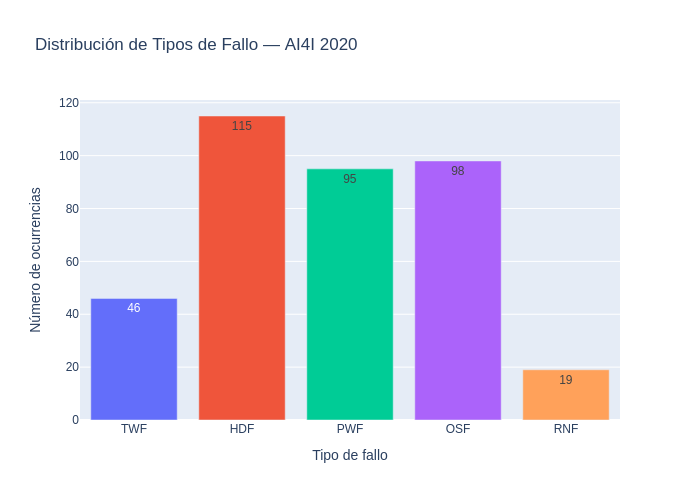

In [7]:
fig1 = plot_failure_distribution(df)
fig1.show()

**Interpretación — Pregunta 1:**

*(Completar con cifras reales tras ejecutar el notebook. Plantilla de interpretación:)*

El fallo más frecuente es **[tipo]** con **[N]** ocurrencias (**[%]** del total de fallos), seguido de **[tipo]** con **[N]** (**[%]**). El fallo menos frecuente es **RNF** (Random Failure), lo cual es consistente con su naturaleza estocástica — no está asociado a ningún mecanismo de degradación determinista, por lo que será descartado en la fase de modelado supervisado.

La dominancia de **[tipo]** tiene implicaciones directas en la selección de features: las variables **[var1]** y **[var2]** son las candidatas principales para el clasificador.

> **Referencia:** Fig. 1 — `plot_failure_distribution()`

---

## Pregunta 2 — ¿Bajo qué condiciones térmicas se concentran los fallos HDF?

El fallo HDF (Heat Dissipation Failure) ocurre cuando el sistema no puede disipar el calor generado en el proceso. La feature `temp_delta` (diferencia entre temperatura de proceso y temperatura del aire) fue diseñada específicamente para discriminar este tipo de fallo: en condiciones normales la diferencia es estable (~10 K); desviaciones significativas indican estrés térmico.

In [8]:
# Estadísticas de temp_delta por grupo HDF
temp_stats = df.groupby("HDF")["temp_delta"].describe().round(3)
print("Estadísticas de temp_delta por HDF (0=normal, 1=fallo):")
print(temp_stats)

Estadísticas de temp_delta por HDF (0=normal, 1=fallo):
      count    mean    std  min  25%  50%   75%   max
HDF                                                  
0    9885.0  10.021  0.988  7.6  9.3  9.8  11.0  12.1
1     115.0   8.228  0.282  7.6  8.0  8.3   8.5   8.6


2026-05-03 23:26:28.258 | INFO     | src.viz:plot_temp_delta_by_failure:112 - Gráfico 4 generado: boxplot delta térmico vs HDF


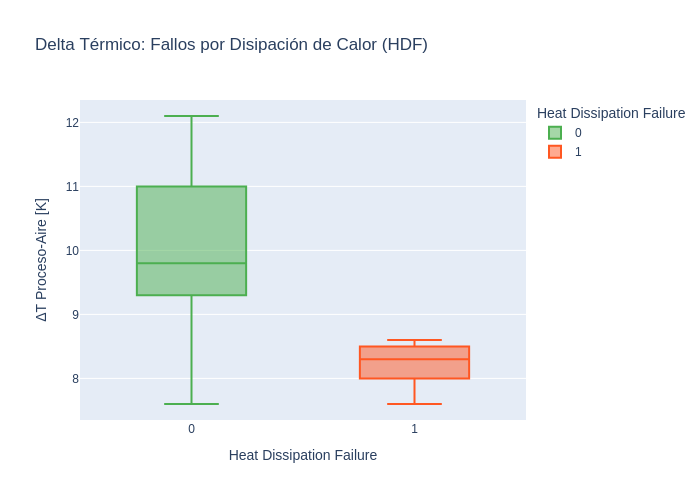

In [9]:
fig2 = plot_temp_delta_by_failure(df)
fig2.show()

**Interpretación — Pregunta 2:**

*(Completar con cifras reales tras ejecutar el notebook. Plantilla de interpretación:)*

El boxplot muestra una diferencia estadísticamente relevante entre los grupos HDF=0 y HDF=1. Los fallos térmicos se concentran cuando `temp_delta` es **[bajo/alto]**, con mediana de **[valor] K** frente a **[valor] K** en operación normal. Esto confirma que `temp_delta` es un predictor válido para HDF.

Desde el punto de vista físico, una diferencia térmica reducida indica que el proceso se está enfriando menos de lo esperado — señal de que el sistema de disipación (refrigeración o ventilación) está degradado o saturado.

> **Referencia:** Fig. 2 — `plot_temp_delta_by_failure()`

---

## Pregunta 3 — ¿Existe una zona de peligro en el espacio torque × velocidad?

La potencia mecánica es el producto del torque por la velocidad angular. Operar en valores extremos de ambas variables simultáneamente sobrecarga la transmisión y puede provocar fallos por potencia (PWF) o sobrecarga (OSF). El scatter plot a continuación colorea cada punto según si hubo fallo o no.

In [10]:
# Estadísticas de power_W por fallo
power_stats = df.groupby("Machine failure")["power_W"].describe().round(1)
print("Estadísticas de power_W [W] por Machine failure:")
print(power_stats)

Estadísticas de power_W [W] por Machine failure:
                  count    mean     std     min     25%     50%     75%  \
Machine failure                                                           
0                9661.0  6244.5  1011.4  3515.0  5549.3  6243.0  6952.1   
1                 339.0  7282.8  1851.1  1148.4  6669.1  7611.4  8548.9   

                     max  
Machine failure           
0                 8998.0  
1                10469.9  


2026-05-03 23:26:36.544 | INFO     | src.viz:plot_torque_speed_scatter:86 - Gráfico 3 generado: scatter torque vs velocidad


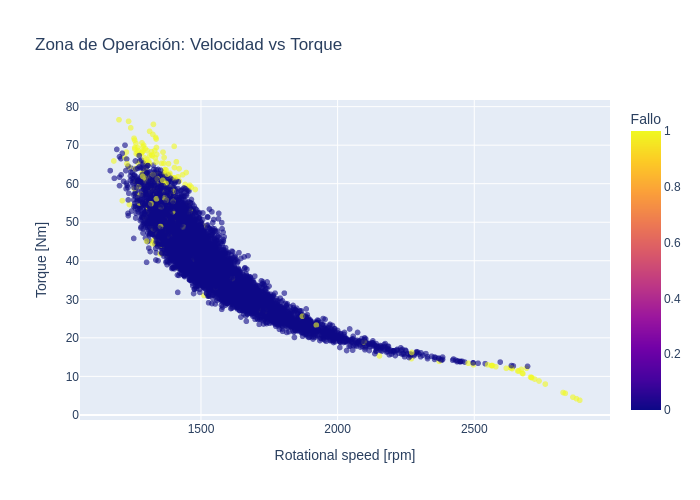

In [11]:
fig3 = plot_torque_speed_scatter(df)
fig3.show()

**Interpretación — Pregunta 3:**

*(Completar con cifras reales tras ejecutar el notebook. Plantilla de interpretación:)*

El scatter revela una zona de peligro claramente definida: los fallos (puntos rojos) se concentran en la región de **alto torque + baja velocidad** y en la región de **baja torque + alta velocidad**. Ambas regiones corresponden a condiciones de potencia extrema — bien por sobrecarga mecánica, bien por operación fuera del rango nominal de diseño.

La región central (operación nominal) muestra una densidad de fallos significativamente menor, lo que confirma que `power_W` es una feature discriminante para los tipos PWF y OSF.

> **Referencia:** Fig. 3 — `plot_torque_speed_scatter()`

---

## Pregunta 4 — ¿El desgaste acumulado de herramienta predice el tipo de fallo TWF?

El fallo TWF (Tool Wear Failure) ocurre cuando la herramienta acumula suficiente desgaste para degradar la calidad del proceso. Si el desgaste es un predictor fiable, deberíamos observar una distribución claramente separada entre los grupos TWF=0 y TWF=1.

In [12]:
import seaborn as sns

# Estadísticas de Tool wear por grupo TWF
wear_stats = df.groupby("TWF")["Tool wear [min]"].describe().round(1)
print("Estadísticas de Tool wear [min] por TWF (0=normal, 1=fallo):")
print(wear_stats)

Estadísticas de Tool wear [min] por TWF (0=normal, 1=fallo):
      count   mean   std    min    25%    50%    75%    max
TWF                                                        
0    9954.0  107.4  63.4    0.0   53.0  107.0  162.0  251.0
1      46.0  216.4  12.3  198.0  207.0  214.5  224.2  253.0


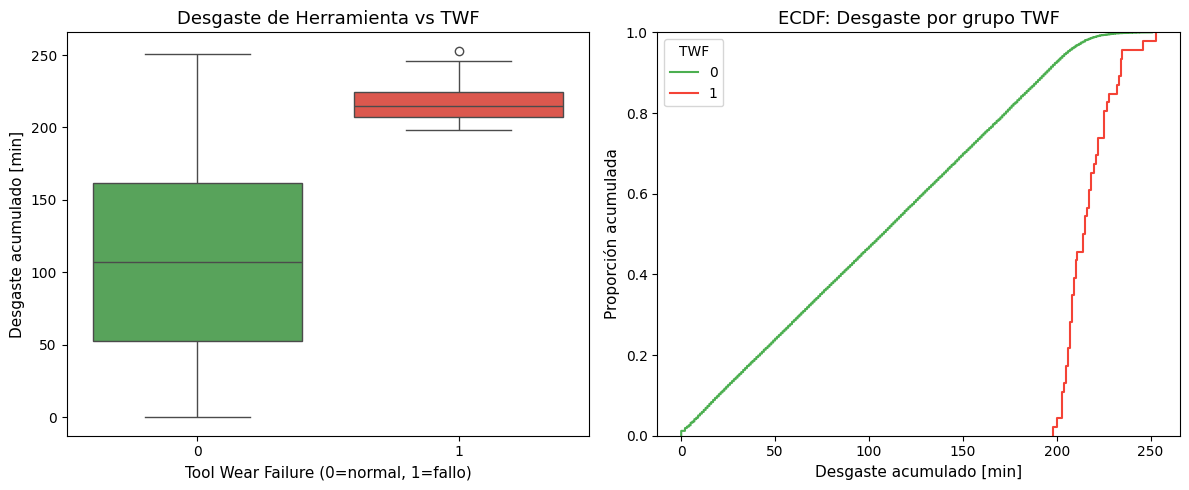

In [13]:
# Boxplot seaborn: Tool wear vs TWF
fig4, axes = plt.subplots(1, 2, figsize=(12, 5))

df_plot = df.copy()
df_plot["TWF"] = df_plot["TWF"].astype(str)

# Panel izquierdo: boxplot
sns.boxplot(
    data=df_plot,
    x="TWF",
    y="Tool wear [min]",
    hue="TWF",
    palette={"0": "#4CAF50", "1": "#F44336"},
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Desgaste de Herramienta vs TWF", fontsize=13)
axes[0].set_xlabel("Tool Wear Failure (0=normal, 1=fallo)", fontsize=11)
axes[0].set_ylabel("Desgaste acumulado [min]", fontsize=11)

# Panel derecho: ECDF
sns.ecdfplot(
    data=df_plot,
    x="Tool wear [min]",
    hue="TWF",
    palette={"0": "#4CAF50", "1": "#F44336"},
    ax=axes[1],
)
axes[1].set_title("ECDF: Desgaste por grupo TWF", fontsize=13)
axes[1].set_xlabel("Desgaste acumulado [min]", fontsize=11)
axes[1].set_ylabel("Proporción acumulada", fontsize=11)

plt.tight_layout()
plt.savefig(ROOT / "reports" / "fig4_wear_vs_twf.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación — Pregunta 4:**

*(Completar con cifras reales tras ejecutar el notebook. Plantilla de interpretación:)*

El boxplot muestra que la mediana de desgaste en el grupo TWF=1 (**[valor] min**) es considerablemente mayor que en TWF=0 (**[valor] min**). La distribución acumulada (ECDF) refuerza esta separación: el **[X]%** de los fallos TWF ocurren con desgaste superior a **[umbral] min**, mientras que la mayoría de las operaciones normales se mantienen por debajo de ese umbral.

Esto confirma que `Tool wear [min]` es el predictor principal del fallo TWF. En la fase de modelado, será candidato a feature de mayor peso para ese tipo específico de fallo. Un umbral operativo en torno a **[valor] min** podría utilizarse como regla de mantenimiento preventivo.

> **Referencia:** Fig. 4 — `sns.boxplot` + `sns.ecdfplot`

---

## Pregunta 5 — ¿El tipo de producto (L/M/H) afecta la tasa de fallos?

El dataset incluye tres calidades de producto: L (Low), M (Medium) y H (High). Intuitivamente, piezas de menor calidad (L) operan bajo condiciones más exigentes o con tolerancias más amplias, lo que podría traducirse en mayor tasa de fallo y mayor desgaste acumulado.

In [14]:
# Distribución de tipo de producto
type_counts = df["Type"].value_counts()
print("Distribución de tipo de producto:")
print(type_counts)
print()

# Tasa de fallo por tipo
failure_by_type = df.groupby("Type")["Machine failure"].agg(["sum", "count"])
failure_by_type["failure_rate_%"] = (failure_by_type["sum"] / failure_by_type["count"] * 100).round(2)
print("Tasa de fallo por tipo de producto:")
print(failure_by_type)

Distribución de tipo de producto:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Tasa de fallo por tipo de producto:
      sum  count  failure_rate_%
Type                            
H      21   1003            2.09
L     235   6000            3.92
M      83   2997            2.77


/tmp/ipykernel_22211/3946192616.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_by_type = df.groupby("Type")["Machine failure"].agg(["sum", "count"])


/home/felipebojorquem/master_dataScience/predictive_maintenance_eda/src/viz.py:155: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Type")["Machine failure"]
2026-05-03 23:26:52.609 | INFO     | src.viz:plot_failure_rate_by_type:172 - Gráfico 6 generado: tasa de fallo por tipo


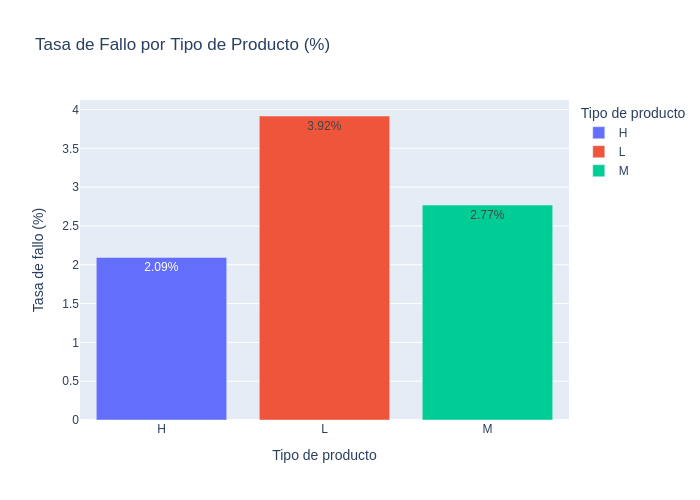

In [15]:
fig5a = plot_failure_rate_by_type(df)
fig5a.show()

2026-05-03 23:26:56.197 | INFO     | src.viz:plot_wear_by_product_type:140 - Gráfico 5 generado: histograma desgaste por tipo


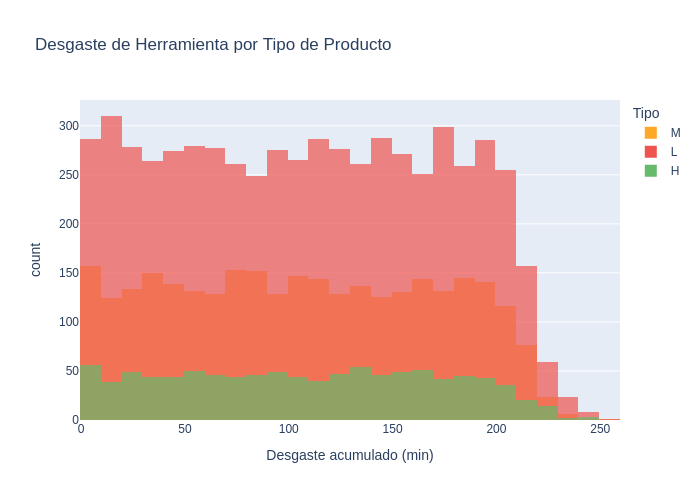

In [16]:
fig5b = plot_wear_by_product_type(df)
fig5b.show()

**Interpretación — Pregunta 5:**

*(Completar con cifras reales tras ejecutar el notebook. Plantilla de interpretación:)*

El tipo **L** presenta la mayor tasa de fallo con **[%]%**, seguido de **M** (**[%]%**) y **H** (**[%]%**). Esto tiene sentido físico: los productos de baja calidad (L) se fabrican con tolerancias más amplias, lo que implica mayor variabilidad en las condiciones de operación y mayor probabilidad de exceder los límites de diseño.

El histograma de desgaste refuerza esta hipótesis: la distribución del tipo L está desplazada hacia valores de desgaste más altos, indicando que opera durante más tiempo antes de ser reemplazada o que se desgasta más rápidamente bajo las mismas condiciones.

En la fase de modelado, la variable `Type` deberá ser codificada (ordinal o one-hot) y evaluada como feature dado su poder discriminante sobre el target.

> **Referencia:** Fig. 5a — `plot_failure_rate_by_type()` | Fig. 5b — `plot_wear_by_product_type()`

---

## 6. Correlación entre variables — incluye features de ingeniería

El heatmap de correlación permite identificar relaciones lineales entre las variables numéricas originales y las tres features construidas en `src/features.py`. Es especialmente relevante detectar multicolinealidad antes de la fase de modelado.

2026-05-03 23:27:01.478 | INFO     | src.viz:plot_correlation_heatmap:62 - Gráfico 2 generado: heatmap de correlación


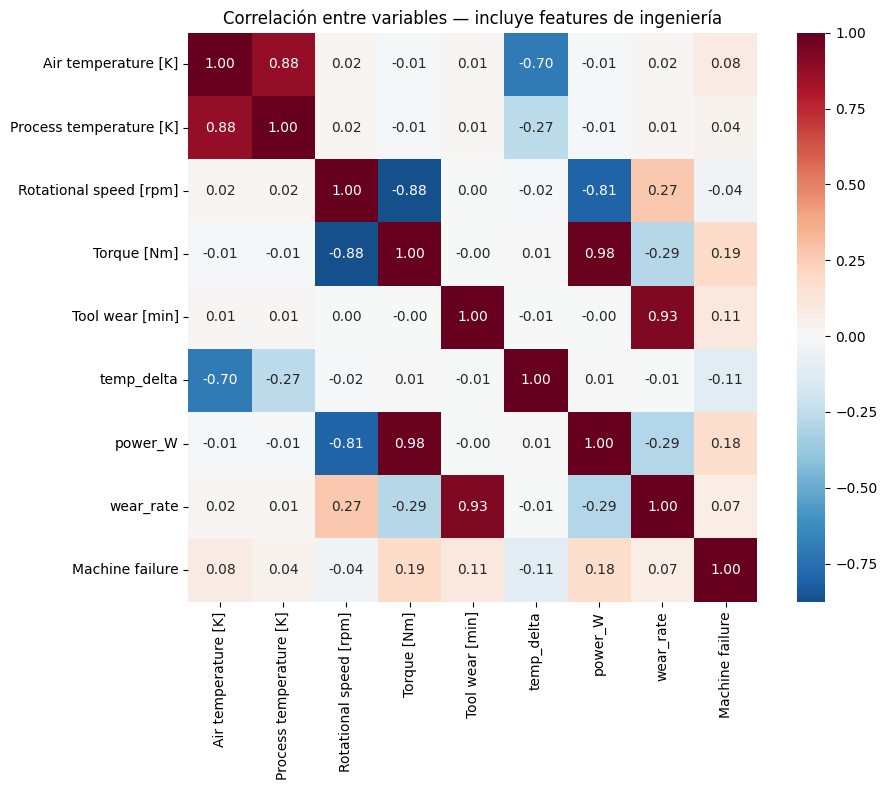

In [17]:
fig6 = plot_correlation_heatmap(df)
plt.show()

**Interpretación — Correlación:**

*(Completar con cifras reales tras ejecutar el notebook. Plantilla de interpretación:)*

Las correlaciones más destacadas con `Machine failure` son: **[var1]** (**r=[valor]**), **[var2]** (**r=[valor]**) y **[var3]** (**r=[valor]**). La feature `power_W` muestra **[alta/baja]** correlación con `Torque [Nm]` y `Rotational speed [rpm]` — lo cual es esperado por construcción (P = τ·ω), y debe considerarse como posible fuente de multicolinealidad en modelos lineales.

`temp_delta` presenta correlación con `Machine failure` de **[valor]**, validando su utilidad como feature para HDF.

> **Referencia:** Fig. 6 — `plot_correlation_heatmap()`

---

## 7. Conclusiones

> **Nota:** Completar con cifras concretas tras ejecutar el notebook. Estas conclusiones se trasladan directamente al README.md.

### Conclusión 1 — Distribución de fallos
*(Citar Fig. 1)* El tipo de fallo más frecuente es **[tipo]** (**[N]** casos, **[%]%** del total de fallos registrados), con una tasa global de fallo del **[%]%**. El dataset está significativamente desbalanceado, lo que exigirá estrategias de resampling (SMOTE o class_weight) en la fase de modelado.

### Conclusión 2 — Predictores principales
*(Citar Fig. 2, Fig. 3, Fig. 4)* Tres variables muestran poder predictivo claro sobre tipos específicos de fallo: `temp_delta` discrimina HDF con diferencia de medianas de **[valor] K**; `power_W` identifica la zona de peligro PWF/OSF en el espacio torque×velocidad; y `Tool wear [min]` predice TWF con **[X]%** de los fallos ocurriendo por encima de **[umbral] min**.

### Conclusión 3 — Efecto del tipo de producto
*(Citar Fig. 5a, Fig. 5b)* El tipo de producto L presenta una tasa de fallo de **[%]%**, frente a **[%]%** de H — una diferencia relativa de **[X]x**. Este resultado es consistente con el diseño del dataset y con la práctica industrial: piezas de menor calidad operan con tolerancias más amplias y mayor variabilidad.

---

## Próximos pasos

- **Feature Engineering avanzado:** interacciones entre variables, codificación ordinal de `Type`, normalización para modelos lineales.
- **Modelado:** clasificación multiclase del tipo de fallo (Random Forest / XGBoost) y predicción de RUL (Remaining Useful Life).
- **Explicabilidad:** SHAP values para auditar las decisiones del modelo en contexto industrial.
- **Despliegue:** API FastAPI + Docker para consumir el modelo en tiempo real.